### Task 1 — Repository Setup

Fork this repository and clone it. Verify the folder structure matches what's described in the main [README](../README.md). Install dependencies with `pip install -r requirements.txt`.

### Task 2 — API Exploration

In `notebooks/day_01_exploration.ipynb`:

1. **Make your first API call.** Fetch one year of daily historical data for Baku (latitude 40.41, longitude 49.87). Print the response structure and identify all available fields.
2. **Visualise a sample.** Plot the daily maximum temperature for the year. Note any gaps or anomalies.
3. **Try the forecast endpoint.** Fetch the current 7-day forecast for the same city. Compare the response structure to the historical endpoint.
4. **Experiment with parameters.** Add at least 3 more weather variables (e.g., precipitation, wind speed, humidity). Document what each variable represents and its unit.

In [1]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas

In [2]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 40.3777,
	"longitude": 49.892,
	"start_date": "2025-04-17",
	"end_date": "2026-04-17",
	"daily": ["weather_code", "temperature_2m_mean", "temperature_2m_max", "temperature_2m_min", "apparent_temperature_max", "apparent_temperature_min", "precipitation_sum", "precipitation_hours", "rain_sum", "snowfall_sum", "wind_speed_10m_max", "wind_gusts_10m_max", "wind_direction_10m_dominant"],
	"hourly": "temperature_2m",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m"] = hourly_temperature_2m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_weather_code = daily.Variables(0).ValuesAsNumpy()
daily_temperature_2m_mean = daily.Variables(1).ValuesAsNumpy()
daily_temperature_2m_max = daily.Variables(2).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(3).ValuesAsNumpy()
daily_apparent_temperature_max = daily.Variables(4).ValuesAsNumpy()
daily_apparent_temperature_min = daily.Variables(5).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(6).ValuesAsNumpy()
daily_precipitation_hours = daily.Variables(7).ValuesAsNumpy()
daily_rain_sum = daily.Variables(8).ValuesAsNumpy()
daily_snowfall_sum = daily.Variables(9).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(10).ValuesAsNumpy()
daily_wind_gusts_10m_max = daily.Variables(11).ValuesAsNumpy()
daily_wind_direction_10m_dominant = daily.Variables(12).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["weather_code"] = daily_weather_code
daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["apparent_temperature_max"] = daily_apparent_temperature_max
daily_data["apparent_temperature_min"] = daily_apparent_temperature_min
daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["precipitation_hours"] = daily_precipitation_hours
daily_data["rain_sum"] = daily_rain_sum
daily_data["snowfall_sum"] = daily_snowfall_sum
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["wind_gusts_10m_max"] = daily_wind_gusts_10m_max
daily_data["wind_direction_10m_dominant"] = daily_wind_direction_10m_dominant

daily_dataframe = pd.DataFrame(data = daily_data)
print("\nDaily data\n", daily_dataframe)


Coordinates: 40.38664245605469°N 49.943660736083984°E
Elevation: -15.0 m asl
Timezone difference to GMT+0: 0s

Hourly data
                           date  temperature_2m
0    2025-04-17 00:00:00+00:00           10.45
1    2025-04-17 01:00:00+00:00           10.60
2    2025-04-17 02:00:00+00:00           10.05
3    2025-04-17 03:00:00+00:00           10.35
4    2025-04-17 04:00:00+00:00           10.55
...                        ...             ...
8779 2026-04-17 19:00:00+00:00           13.00
8780 2026-04-17 20:00:00+00:00           12.80
8781 2026-04-17 21:00:00+00:00           12.60
8782 2026-04-17 22:00:00+00:00           12.45
8783 2026-04-17 23:00:00+00:00           12.25

[8784 rows x 2 columns]

Daily data
                          date  weather_code  temperature_2m_mean  \
0   2025-04-17 00:00:00+00:00          51.0            10.829166   
1   2025-04-18 00:00:00+00:00           3.0            11.206250   
2   2025-04-19 00:00:00+00:00           3.0            12.270832   
3 

In [3]:
print("=== RESPONSE STRUCTURE ===")

print("Latitude:", response.Latitude())
print("Longitude:", response.Longitude())
print("Elevation:", response.Elevation())
print("Timezone offset (sec):", response.UtcOffsetSeconds())

print("\nAvailable Sections:")
print("- Daily data:", response.Daily())
print("- Hourly data:", response.Hourly())
print("- Current data:", "NOT available in historical API")

# Daily fields
daily = response.Daily()
print("\n=== DAILY VARIABLES ===")
for i in range(len(params["daily"])):
    print(i, params["daily"][i])

=== RESPONSE STRUCTURE ===
Latitude: 40.38664245605469
Longitude: 49.943660736083984
Elevation: -15.0
Timezone offset (sec): 0

Available Sections:
- Daily data: <openmeteo_sdk.VariablesWithTime.VariablesWithTime object at 0x12823b520>
- Hourly data: <openmeteo_sdk.VariablesWithTime.VariablesWithTime object at 0x128283a00>
- Current data: NOT available in historical API

=== DAILY VARIABLES ===
0 weather_code
1 temperature_2m_mean
2 temperature_2m_max
3 temperature_2m_min
4 apparent_temperature_max
5 apparent_temperature_min
6 precipitation_sum
7 precipitation_hours
8 rain_sum
9 snowfall_sum
10 wind_speed_10m_max
11 wind_gusts_10m_max
12 wind_direction_10m_dominant


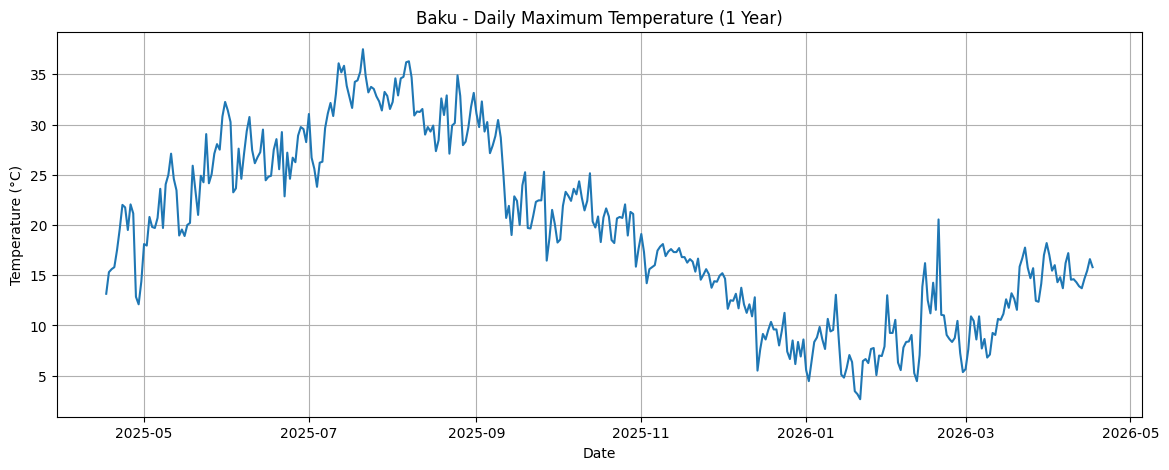

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    daily_dataframe["date"],
    daily_dataframe["temperature_2m_max"]
)

plt.title("Baku - Daily Maximum Temperature (1 Year)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid()

plt.show()

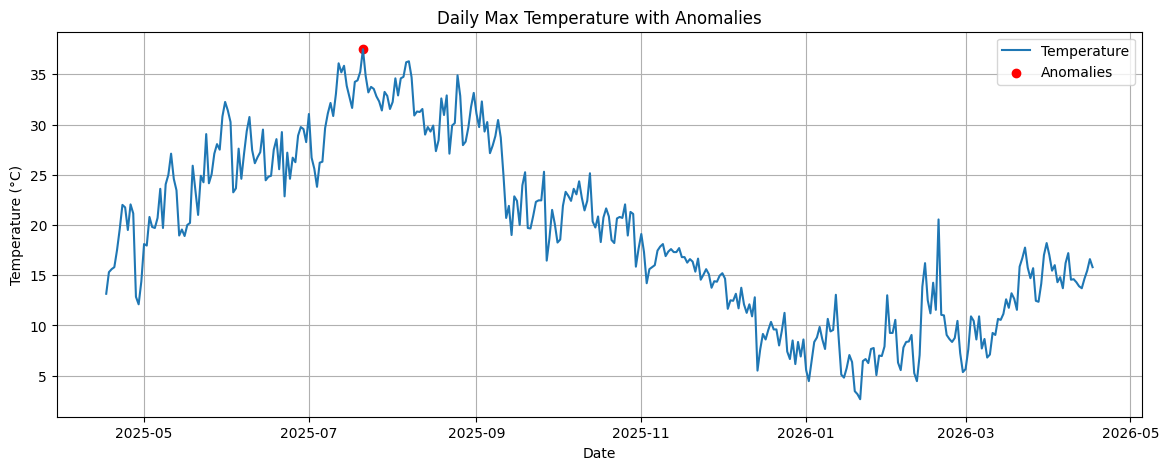

In [5]:
mean_temp = daily_dataframe["temperature_2m_max"].mean()
std_temp = daily_dataframe["temperature_2m_max"].std()

threshold = 2 * std_temp

anomalies = daily_dataframe[
    abs(daily_dataframe["temperature_2m_max"] - mean_temp) > threshold
]

plt.figure(figsize=(14, 5))

plt.plot(
    daily_dataframe["date"],
    daily_dataframe["temperature_2m_max"],
    label="Temperature"
)

plt.scatter(
    anomalies["date"],
    anomalies["temperature_2m_max"],
    color="red",
    label="Anomalies"
)

plt.title("Daily Max Temperature with Anomalies")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid()

plt.show()

### Temperature Visualisation Insights

The plot shows a clear seasonal pattern:
- Higher temperatures during summer months
- Lower temperatures during winter

No major gaps were observed in the data, which indicates good data quality.

Only one clear anomaly was detected in the dataset, occurring in the summer of 2025. This likely represents an extreme heatwave event. Such extreme conditions are important for our project because they directly relate to construction heat risk and worker safety limits.

In [6]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": 40.3777,
	"longitude": 49.892,
	"daily": ["temperature_2m_max", "weather_code", "temperature_2m_min", "apparent_temperature_max", "apparent_temperature_min", "rain_sum", "snowfall_sum", "precipitation_sum", "precipitation_hours", "wind_speed_10m_max", "wind_gusts_10m_max", "wind_direction_10m_dominant"],
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_max = daily.Variables(0).ValuesAsNumpy()
daily_weather_code = daily.Variables(1).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(2).ValuesAsNumpy()
daily_apparent_temperature_max = daily.Variables(3).ValuesAsNumpy()
daily_apparent_temperature_min = daily.Variables(4).ValuesAsNumpy()
daily_rain_sum = daily.Variables(5).ValuesAsNumpy()
daily_snowfall_sum = daily.Variables(6).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(7).ValuesAsNumpy()
daily_precipitation_hours = daily.Variables(8).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(9).ValuesAsNumpy()
daily_wind_gusts_10m_max = daily.Variables(10).ValuesAsNumpy()
daily_wind_direction_10m_dominant = daily.Variables(11).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["weather_code"] = daily_weather_code
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["apparent_temperature_max"] = daily_apparent_temperature_max
daily_data["apparent_temperature_min"] = daily_apparent_temperature_min
daily_data["rain_sum"] = daily_rain_sum
daily_data["snowfall_sum"] = daily_snowfall_sum
daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["precipitation_hours"] = daily_precipitation_hours
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["wind_gusts_10m_max"] = daily_wind_gusts_10m_max
daily_data["wind_direction_10m_dominant"] = daily_wind_direction_10m_dominant

daily_dataframe = pd.DataFrame(data = daily_data)
print("\nDaily data\n", daily_dataframe)


Coordinates: 40.375°N 49.875°E
Elevation: -15.0 m asl
Timezone difference to GMT+0: 0s

Daily data
                        date  temperature_2m_max  weather_code  \
0 2026-04-20 00:00:00+00:00           14.910501          80.0   
1 2026-04-21 00:00:00+00:00           11.460501          80.0   
2 2026-04-22 00:00:00+00:00           15.160501           3.0   
3 2026-04-23 00:00:00+00:00           15.360500           3.0   
4 2026-04-24 00:00:00+00:00           16.310501           2.0   
5 2026-04-25 00:00:00+00:00           14.560500           3.0   
6 2026-04-26 00:00:00+00:00           18.464001           3.0   

   temperature_2m_min  apparent_temperature_max  apparent_temperature_min  \
0           10.960501                 11.279022                  6.130590   
1            9.560500                  8.845315                  5.662177   
2           10.760500                 14.593527                  8.400435   
3           10.360500                 14.735100                  5.7431

In [7]:
print("=== RESPONSE STRUCTURE (FORECAST) ===")

print("Latitude:", response.Latitude())
print("Longitude:", response.Longitude())
print("Elevation:", response.Elevation())
print("Timezone offset (sec):", response.UtcOffsetSeconds())

print("\nAvailable Sections:")

print("- Daily:", response.Daily())
print("- Hourly:", response.Hourly())
print("- Current:", response.Current())

daily = response.Daily()

print("\n=== DAILY VARIABLES ===")
for i in range(len(params["daily"])):
    print(i, params["daily"][i])

=== RESPONSE STRUCTURE (FORECAST) ===
Latitude: 40.375
Longitude: 49.875
Elevation: -15.0
Timezone offset (sec): 0

Available Sections:
- Daily: <openmeteo_sdk.VariablesWithTime.VariablesWithTime object at 0x16a1e5e70>
- Hourly: None
- Current: None

=== DAILY VARIABLES ===
0 temperature_2m_max
1 weather_code
2 temperature_2m_min
3 apparent_temperature_max
4 apparent_temperature_min
5 rain_sum
6 snowfall_sum
7 precipitation_sum
8 precipitation_hours
9 wind_speed_10m_max
10 wind_gusts_10m_max
11 wind_direction_10m_dominant


### Daily Variables

* **weathercode** — General weather condition (clear, fog, storm); used to understand overall daily risk level
* **temperature_2m_max** — Maximum daily temperature; used to detect overheating and fast concrete drying risk
* **temperature_2m_min** — Minimum daily temperature; used to detect freezing risk for materials
* **apparent_temperature_max** — Feels-like max temperature; used for worker heat stress risk (HSE)
* **apparent_temperature_min** — Feels-like min temperature; used for cold exposure risk for workers
* **precipitation_sum** — Total daily precipitation (mm); used to detect flooding risk in construction areas
* **precipitation_hours** — Duration of precipitation; used for planning logistics and work schedules
* **rain_sum** — Total rainfall (mm); used to distinguish rain impact from snow
* **snowfall_sum** — Total snowfall (cm); used for roof load and access road risks
* **windspeed_10m_max** — Maximum wind speed (m/s); used to determine crane operation safety limits
* **windgusts_10m_max** — Maximum wind gusts (m/s); used to detect sudden dangerous wind conditions
* **winddirection_10m_dominant** — Dominant wind direction; used to adjust crane positioning and site operations


### Task 3 — City & Variable Selection

Choose your 3+ cities and document:

| City | Latitude | Longitude | Why this city? |
|------|----------|-----------|----------------|
| Baku | 40.41 | 49.87 | Home city, local relevance |
| ... | ... | ... | ... |

Choose at least **6 daily weather variables** you will track. For each variable, note: name, unit, and why it is relevant to your analysis.



## 1. Selected Cities

| City | Latitude | Longitude | Why this city? |
|------|----------|-----------|-----------------|
| Baku | 40.41 | 49.87 | Capital city, main construction activity, coastal climate with wind and humidity risks |
| Ganja | 40.68 | 46.36 | Inland city with strong seasonal temperature changes, good for climate variation analysis |
| Shusha | 39.76 | 46.75 | Mountain region with extreme weather changes, snowfall and wind risks |
| Nakhchivan | 39.21 | 45.41 | Dry continental climate with high temperature extremes and low precipitation |

---

## 2. Daily Weather Variables (Core Features)

---

### weathercode
**Unit:** WMO code (categorical)  
**Why it matters:**  
General weather condition (clear, fog, storm). Used to understand overall daily construction risk level.

---

### temperature_2m_max
**Unit:** °C  
**Why it matters:**  
Maximum daily temperature. Used to detect overheating and fast concrete drying risk.

---

### temperature_2m_min
**Unit:** °C  
**Why it matters:**  
Minimum daily temperature. Used to detect freezing risk for construction materials.

---

### apparent_temperature_max
**Unit:** °C  
**Why it matters:**  
Feels-like maximum temperature. Used for worker heat stress and HSE safety limits.

---

### apparent_temperature_min
**Unit:** °C  
**Why it matters:**  
Feels-like minimum temperature. Used for cold exposure risk for workers.

---

### precipitation_sum
**Unit:** mm  
**Why it matters:**  
Total daily precipitation. Used to detect flooding risk in excavation and foundation works.

---

### precipitation_hours
**Unit:** hours  
**Why it matters:**  
Duration of precipitation. Used for planning work schedules and downtime estimation.

---

### rain_sum
**Unit:** mm  
**Why it matters:**  
Pure rainfall amount. Helps distinguish rain-specific impact from mixed precipitation.

---

### snowfall_sum
**Unit:** cm  
**Why it matters:**  
Total snowfall. Used for structural load risk and access problems, especially in mountain regions.

---

### windspeed_10m_max
**Unit:** m/s  
**Why it matters:**  
Maximum wind speed. Used for crane operation safety and stopping heavy lifting work.

---

### windgusts_10m_max
**Unit:** m/s  
**Why it matters:**  
Sudden wind gusts. Used to detect short-term dangerous spikes affecting cranes and scaffolding.

---

### winddirection_10m_dominant
**Unit:** degrees (°)  
**Why it matters:**  
Main wind direction. Used for adjusting crane positioning and optimizing construction site safety.

---

## Summary

These cities represent different climate zones of Azerbaijan, and the selected variables directly support construction risk prediction.

They will be used to build models for:
- Safe vs risky day classification
- Risk intensity estimation (regression)
- Long-term construction planning support

### Task 4 — Project Plan

Update the `README.md` in your fork with:

- **Problem statement**: What question will your prediction model try to answer?
- **Data sources**: Which API endpoints and parameters you will use
- **Cities and variables**: Your selections from Task 3
- **Methodology outline**: High-level approach for each week
- **Success criteria**: How will you evaluate your pipeline and your model?


---

## 1. Problem Statement

Most weather applications only provide forecasts for the next 7 days. However, construction companies need to plan their operations weeks in advance.

Our goal is to build a model that predicts **construction risk conditions for the next 30 days beyond the standard 7-day forecast window**.

For example, if today is April 19, the model will predict risks for the period **April 26 → May 26**, helping companies understand how many days will be unsafe for construction work.

---

## 2. Why It Matters

Construction projects (buildings, bridges, and residential complexes) are highly affected by weather conditions.

Unexpected weather can cause:

- Work stoppages  
- Equipment downtime  
- Material damage  
- Worker safety risks  

This leads to **financial losses and delays**.

By predicting future risk days, this system helps:

- Plan construction schedules in advance  
- Reduce costs caused by delays  
- Improve worker safety (HSE standards)  
- Optimize use of equipment and materials  

This turns weather data into a **decision-support system**, not just a forecast.

---

## 3. Data Sources

We will use Open-Meteo API endpoints:

### Historical Data
- Endpoint: `https://archive-api.open-meteo.com/v1/archive`
- Purpose: Model training and pattern learning
- Parameters:
  - latitude, longitude (city-based)
  - start_date, end_date (multi-year historical data)
  - daily + hourly weather variables

### Forecast Data
- Endpoint: `https://api.open-meteo.com/v1/forecast`
- Purpose: 7-day validation and comparison with historical patterns
- Parameters:
  - latitude, longitude
  - daily + hourly variables
  - current weather (for live dashboard)

---

## 4. Cities / Locations

We selected multiple cities with different climate conditions:

- **Baku** (40.41, 49.87) — coastal, high wind and humidity influence  
- **Ganja** (40.68, 46.36) — inland, seasonal temperature variation  
- **Shusha** (39.76, 46.75) — mountainous, snowfall and wind risks  
- **Nakhchivan** (39.21, 45.41) — dry continental climate, extreme temperatures  

---

## 5. Weather Variables

We use a multi-layer feature set (daily + hourly + current) to capture construction risk behavior.

### Daily Variables (Core Features)

- **weathercode** — General weather condition (clear, fog, storm); used to classify overall risk level  
- **temperature_2m_max** — Maximum daily temperature; used for overheating and concrete drying risk  
- **temperature_2m_min** — Minimum daily temperature; used for freezing risk of materials  
- **apparent_temperature_max** — Feels-like max temperature; used for worker heat stress (HSE risk)  
- **apparent_temperature_min** — Feels-like min temperature; used for cold exposure risk  
- **precipitation_sum** — Total precipitation (mm); used for flooding risk in construction sites  
- **precipitation_hours** — Duration of rainfall; used for scheduling work interruptions  
- **rain_sum** — Total rainfall (mm); used for rain-specific construction disruption analysis  
- **snowfall_sum** — Snow amount (cm); used for structural load and accessibility risks  
- **windspeed_10m_max** — Maximum wind speed; used for crane safety and stopping operations  
- **windgusts_10m_max** — Wind gusts; used for sudden instability detection  
- **winddirection_10m_dominant** — Wind direction; used for crane positioning and site planning  

---

### Hourly Variables (Feature Engineering Layer)

- **temperature_2m** — Hourly temperature; used to capture daily thermal patterns  
- **apparent_temperature** — Feels-like temperature; used for peak worker stress hours  
- **relative_humidity_2m** — Humidity (%); used for drying and coating conditions  
- **precipitation** — Hourly precipitation; used for precise stop-work timing  
- **windspeed_10m** — Hourly wind speed; used for wind pattern analysis  
- **windgusts_10m** — Wind gust spikes; used for short-term risk detection  
- **weathercode** — Hourly weather condition; used to refine daily classification  
- **surface_pressure** — Surface pressure; used for wind behavior estimation  
- **sea_level_pressure** — Sea level pressure; used for storm and wind forecasting patterns  

---

### Current Variables (Live Dashboard)

- **temperature_2m** — Current temperature; used for real-time site monitoring  
- **windspeed_10m** — Current wind speed; used for crane safety alerts  
- **windgusts_10m** — Current wind gusts; used for sudden risk detection  
- **weathercode** — Current weather condition; used for live risk visualization  

---

## 6. Methodology Outline

### Week 1 — Data Understanding & Feature Engineering
- API integration (historical + forecast)
- Data cleaning and alignment
- Feature engineering from hourly → daily aggregation
- Risk label creation (binary + percentage risk)

### Week 2 — Modeling
- Classification models:
  - Logistic Regression
  - Random Forest
- Regression models:
  - Risk probability estimation
- Feature importance analysis
- Model comparison

### Week 3 — Evaluation & Improvement
- Cross-validation
- Class imbalance handling
- Threshold tuning
- Final model selection

### Week 4 — Deployment Concept
- Simple dashboard design
- City selector
- Risk calendar visualization (30-day window)

---

## 7. Success Criteria

The project will be considered successful if:

- The model can predict **construction risk days beyond the 7-day forecast window**
- Classification model achieves reliable performance (F1-score > baseline)
- Regression model provides meaningful risk probability estimates
- Feature importance aligns with real-world construction logic (wind, rain, temperature)
- Results are consistent across all 4 cities
- System provides actionable insights for planning (not just predictions)

---

## Summary

This project transforms weather forecasting into a **construction decision-support system**, enabling companies to plan long-term operations using both classification (safe/risky) and regression (risk intensity) outputs.